In [2]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import re
import unicodedata
from sodapy import Socrata
import plotly.graph_objects as go
import geopandas as gpd
from shapely.geometry import Point
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option("display.max_seq_items", None)

## Direcciones 

os.getcwd()
os.chdir("C:\\Users\\Usuario\\OneDrive - Global Green Growth Institute\\Documentos\\2025\\Outputs\\Output1\\Stress Test\\3.Data\\")
print("Lista de archivos:",os.listdir())


Lista de archivos: ['.git', '09012026 Datos SFC (Revisado por la SFC).xlsx', '202510_Lista de Variables.xlsx', 'cartera_banco_municipio_322.csv', 'cartera_por_banco_322.csv', 'city_scale_climate_hazards_at_1p5_2_3_C_warming', 'Datos Procesados', 'Datos SFC.xlsx', 'DatosMensuales_HumedadRelativa_SSP126_2021-2100.txt', 'datos_municipios.csv', 'Escenarios Cambio Climatico IDEAM IV comunicacion', 'F1000-141 formato 239.xlsx', 'Flujo Mensual.xlsx', 'Formatos SFC por tipo de entidad.xlsx', 'Fuentes de datos DNP.xlsx', 'Fuentes de datos.xlsx', 'index.html', 'Información 25022026', 'Información SFC', 'Precipitación_20251222.csv', 'Precipitación_20251222_2.csv', 'Scripts Python', 'sfc_322.csv', 'Solicitud de Información 27012026.xlsx']


In [3]:
pip install socrata

  Using cached socrata-0.0.1.tar.gz (1.2 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [25 lines of output]
      Traceback (most recent call last):
        File "c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\Usuario\AppData\Local\Temp\pip-build-env-ieuyw2fn\overlay\Lib\si

In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Precipitación historica**

In [6]:
precipitacion=pd.read_csv("Precipitación_20251222.csv")

for col in ["Latitud", "Longitud","ValorObservado"]:
    precipitacion[col] = (
        precipitacion[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
        .replace("nan", None)
        .astype(float)
    )

fecha_str_ = precipitacion["FechaObservacion"].str.slice(0, 11)

precipitacion["fecha"] = pd.to_datetime(
    fecha_str_,
    format="%Y %b %d",
    errors="coerce",
    cache=True
)

In [7]:
station_cols = [
    "CodigoEstacion",
    "NombreEstacion",
    "Departamento",
    "Municipio",
    "ZonaHidrografica",
    "Latitud",
    "Longitud"
]

df_daily = (
    precipitacion
    .groupby(station_cols + ["fecha"], as_index=False)
    .agg(
        precip_min_10min=("ValorObservado", "min"),
        precip_max_10min=("ValorObservado", "max"),
        precip_media_10min=("ValorObservado", "mean"),
        precip_acum_diaria=("ValorObservado", "sum")
    )
)

df_daily = df_daily.sort_values(
    ["CodigoEstacion", "fecha"]
)
df_daily.head()

,CodigoEstacion,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,fecha,precip_min_10min,precip_max_10min,precip_media_10min,precip_acum_diaria
0,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-19,0.0,0.1,0.000526,0.1
1,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-20,0.0,0.0,0.000000,0.0
2,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-21,0.0,0.1,0.000347,0.1
3,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-22,0.0,0.1,0.000347,0.1
4,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-23,0.0,0.0,0.000000,0.0


In [8]:
data_2 = pd.read_csv("Precipitación_20251222_2.csv",decimal=",")

for col in ["Latitud", "Longitud","ValorObservado"]:
    data_2[col] = (
        data_2[col].astype(float)
    )
data_2.head()  

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,15015120,240.0,2015 Feb 08 02:00:00 PM,0.0,UNIVERSIDAD TECNOLOGICA - AUT,MAGDALENA,SANTA MARTA,CARIBE - GUAJIRA,11.223056,-74.185917,Precipitacion,mm
1,2120000109,240.0,2018 Dec 31 08:09:00 PM,0.0,COLEGIO RODOLFO LLINAS - AUT,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.720000,-74.108000,Precipitacion,mm
2,52055502,240.0,2017 Mar 23 11:45:00 AM,0.0,SANDONA - AUT,NARIÑO,SANDONÁ,PATÍA,1.300889,-77.460358,Precipitacion,mm
3,21255170,240.0,2010 Oct 30 03:10:00 AM,0.1,MURILLO - AUT,TOLIMA,MURILLO,ALTO MAGDALENA,4.870556,-75.173278,Precipitacion,mm
4,21197010,240.0,2015 Dec 20 08:20:00 PM,0.0,EL PROFUNDO - AUT,CUNDINAMARCA,CABRERA,ALTO MAGDALENA,4.011694,-74.504444,Precipitacion,mm


In [9]:
fecha_str = data_2["FechaObservacion"].str.slice(0, 11)

data_2["fecha"] = pd.to_datetime(
    fecha_str,
    format="%Y %b %d",
    errors="coerce",
    cache=True
)

In [10]:
station_cols = [
    "CodigoEstacion",
    "NombreEstacion",
    "Departamento",
    "Municipio",
    "ZonaHidrografica",
    "Latitud",
    "Longitud"
]

df_daily_2 = (
    data_2
    .groupby(station_cols + ["fecha"], as_index=False)
    .agg(
        precip_min_10min=("ValorObservado", "min"),
        precip_max_10min=("ValorObservado", "max"),
        precip_media_10min=("ValorObservado", "mean"),
        precip_acum_diaria=("ValorObservado", "sum")
    )
)

df_daily_2 = df_daily_2.sort_values(
    ["CodigoEstacion", "fecha"]
)
df_daily_2.head()

,CodigoEstacion,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,fecha,precip_min_10min,precip_max_10min,precip_media_10min,precip_acum_diaria
0,11017020,PR CHOCO: BAGADO,CHOCÓ,BAGADÓ,<nil>,5.412,-76.418,2018-05-04,0.0,3.0,0.147826,3.4
1,11017020,PR CHOCO: BAGADO,CHOCÓ,BAGADÓ,<nil>,5.412,-76.418,2018-05-05,0.0,2.5,0.171429,8.4
2,11017020,PR CHOCO: BAGADO,CHOCÓ,BAGADÓ,<nil>,5.412,-76.418,2018-05-06,0.0,0.0,0.000000,0.0
3,11017020,PR CHOCO: BAGADO,CHOCÓ,BAGADÓ,<nil>,5.412,-76.418,2018-05-07,0.0,6.3,0.206818,9.1
4,11017020,PR CHOCO: BAGADO,CHOCÓ,BAGADÓ,<nil>,5.412,-76.418,2018-05-08,0.0,0.0,0.000000,0.0


In [55]:
df_daily_vf=pd.concat([df_daily,df_daily_2])
df_daily_vf=df_daily_vf.drop_duplicates(["CodigoEstacion","fecha"])
print(df_daily_vf.shape)
df_daily_vf.head()

(976941, 12)


,CodigoEstacion,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,fecha,precip_min_10min,precip_max_10min,precip_media_10min,precip_acum_diaria
0,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-19,0.0,0.1,0.000526,0.1
1,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-20,0.0,0.0,0.000000,0.0
2,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-21,0.0,0.1,0.000347,0.1
3,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-22,0.0,0.1,0.000347,0.1
4,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,ATRATO - DARIÉN,5.888719,-76.145167,2022-12-23,0.0,0.0,0.000000,0.0


In [56]:
df_daily_vf['fecha'] = pd.to_datetime(df_daily_vf['fecha'])
df_daily_vf['mes'] = df_daily_vf['fecha'].dt.month

# 1. Percentil 95 por estación y mes
p95 = df_daily_vf.groupby(['CodigoEstacion', 'mes'])['precip_acum_diaria'].quantile(0.95).reset_index()
p95.columns = ['CodigoEstacion', 'mes', 'p95']

# 2. Eventos extremos
df_daily_vf = df_daily_vf.merge(p95, on=['CodigoEstacion', 'mes'], how='left')
df_daily_vf['extremo'] = (df_daily_vf['precip_acum_diaria'] > df_daily_vf['p95']).astype(int)

# 3. Frecuencia y alerta por estación
estaciones_alerta = df_daily_vf.groupby(['CodigoEstacion', 'NombreEstacion', 'Departamento', 'Municipio', 
                                          'Latitud', 'Longitud'])['extremo'].mean().reset_index()

estaciones_alerta.columns = [*estaciones_alerta.columns[:-1], 'frecuencia_extremos']
estaciones_alerta['alerta'] = (estaciones_alerta['frecuencia_extremos'] > 0.1).astype(int)
print(estaciones_alerta['alerta'].value_counts())
estaciones_alerta.head()

alerta
0    2717
1     336
Name: count, dtype: int64


,CodigoEstacion,NombreEstacion,Departamento,Municipio,Latitud,Longitud,frecuencia_extremos,alerta
0,11017020,PR CHOCO: BAGADO,CHOCÓ,BAGADÓ,5.412000,-76.418000,0.060748,0
1,11025501,CARMEN DE ATRATO - AUT,CHOCO,EL CARMEN,5.888719,-76.145167,0.055305,0
2,11027030,EL SIETE,CHOCO,EL CARMEN,5.862000,-76.152056,0.033708,0
3,11027030,EL SIETE - AUT,CHOCO,EL CARMEN,5.862000,-76.152056,0.102041,1
4,11027070,BORAUDO,CHOCÓ,LLORÓ,5.515000,-76.576000,0.051806,0


In [60]:
# ── Carga davipola y proyecta a EPSG 3116 ────────────────────────────────────
# (se hace una sola vez sobre ~1400 estaciones únicas, no sobre los 978K registros diarios)
MENSUALES_DIR = (
    r"C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos"
    r"\2025\Outputs\Output1\Stress Test\3.Data"
    r"\Escenarios Cambio Climatico IDEAM IV comunicacion\Mensuales"
)
davipola = pd.read_excel(os.path.join(MENSUALES_DIR, "davipola_dane.xlsx"))

gdf_mun = gpd.GeoDataFrame(
    davipola,
    geometry=gpd.points_from_xy(davipola.LONGITUD, davipola.LATITUD),
    crs="EPSG:4326",
).to_crs(epsg=3116)

print(f"Municipios cargados: {len(gdf_mun)}")

Municipios cargados: 1121


In [ ]:
# ── Consulta API IDEAM – último día disponible ────────────────────────────────
DATASET_ID = "s54a-sgyg"
client = Socrata("www.datos.gov.co", None)
fecha_mapa = client.get(DATASET_ID, select="max(fechaobservacion)")[0]["max_fechaobservacion"][:10]
print(f"Última fecha disponible: {fecha_mapa}")

where = (
    f"fechaobservacion >= '{fecha_mapa}T00:00:00' "
    f"AND fechaobservacion < '{fecha_mapa}T23:59:59.999'"
)

records, offset = [], 0
while True:
    batch = client.get(DATASET_ID, where=where, limit=100_000, offset=offset)
    if not batch:
        break
    records.extend(batch)
    offset += 100_000
    print(f"  {len(records):,} registros descargados…")
client.close()

# ── Agrega a nivel de estación ────────────────────────────────────────────────
df_api = pd.DataFrame.from_records(records)

for col in ("valorobservado", "latitud", "longitud"):
    df_api[col] = pd.to_numeric(df_api[col], errors="coerce")

df_api = df_api.dropna(subset=["latitud", "longitud", "valorobservado"])
df_api = df_api[df_api["valorobservado"] >= 0]

STATION_COLS_API = [
    "codigoestacion", "nombreestacion", "departamento",
    "municipio", "zonahidrografica", "latitud", "longitud",
]

df_dia = (
    df_api.groupby(STATION_COLS_API, as_index=False)
    .agg(
        precip_acum_mm   = ("valorobservado", "sum"),
        precip_max_10min = ("valorobservado", "max"),
        n_lecturas       = ("valorobservado", "count"),
    )
)
del df_api
# ── Fusión con alerta histórica ───────────────────────────────────────────────
estaciones_alerta["cod_norm"] = estaciones_alerta["CodigoEstacion"].astype(str).str.strip().str.lstrip("0")
df_dia["cod_norm"]            = df_dia["codigoestacion"].astype(str).str.strip().str.lstrip("0")

df_dia = df_dia.merge(
    estaciones_alerta[["cod_norm", "alerta", "frecuencia_extremos"]],
    on="cod_norm",
    how="left"
)

df_dia["alerta"]              = df_dia["alerta"].fillna(0).astype(int)
df_dia["frecuencia_extremos"] = df_dia["frecuencia_extremos"].fillna(0)

# ── Diagnóstico del merge (opcional) ─────────────────────────────────────────
matched = df_dia["alerta"].sum()
print(f"Estaciones activas hoy       : {len(df_dia):,}")
print(f"  Con alerta histórica        : {matched:,}")
print(f"  Sin match en histórico      : {(df_dia['frecuencia_extremos'] == 0).sum():,}")

# ── Sjoin sobre estaciones → asignación de municipio ─────────────────────────
gdf_dia = gpd.GeoDataFrame(
    df_dia,
    geometry=gpd.points_from_xy(df_dia.longitud, df_dia.latitud),
    crs="EPSG:4326",
).to_crs(epsg=3116)

df_muni = gpd.sjoin_nearest(gdf_mun, gdf_dia, how="left", distance_col="dist_m")

# ── Agrupación a nivel municipal ──────────────────────────────────────────────
df_muni = (
    df_muni
    .groupby(["COD_MPIO", "NOM_MPIO", "NOM_DPTO", "LATITUD", "LONGITUD"], as_index=False)
    .agg(
        precip_acum_mm      = ("precip_acum_mm",      "mean"),
        precip_max_10min    = ("precip_max_10min",     "max"),
        n_estaciones        = ("codigoestacion",       "count"),
        alerta              = ("alerta",               "max"),
        frecuencia_extremos = ("frecuencia_extremos",  "max"),
    )
)

df_muni["alerta"] = df_muni["alerta"].fillna(0).astype(int)

print(f"Municipios con datos         : {len(df_muni):,}")
print(f"Municipios con alerta        : {df_muni['alerta'].sum():,}")

Última fecha disponible: 2026-03-07
  100,000 registros descargados…
  170,458 registros descargados…
Estaciones activas hoy       : 2,219
  Con alerta histórica        : 280
  Sin match en histórico      : 845
Municipios con datos         : 1,121
Municipios con alerta        : 326


In [66]:
from plotly.subplots import make_subplots

# ── Categorías y colores ──────────────────────────────────────────────────────
ORDEN_CAT = [
    "Sin lluvia (0 mm)", "Muy ligera (< 5 mm)", "Ligera (5–15 mm)",
    "Moderada (15–30 mm)", "Fuerte (30–60 mm)", "Muy fuerte (60–100 mm)", "Extrema (≥ 100 mm)",
]
COLOR_MAP = {
    "Sin lluvia (0 mm)":      "#d4e6f1",
    "Muy ligera (< 5 mm)":    "#85c1e9",
    "Ligera (5–15 mm)":       "#2e86c1",
    "Moderada (15–30 mm)":    "#1a5276",
    "Fuerte (30–60 mm)":      "#f39c12",
    "Muy fuerte (60–100 mm)": "#e74c3c",
    "Extrema (≥ 100 mm)":     "#7b241c",
}

def categoria_precip(mm):
    if mm == 0:    return "Sin lluvia (0 mm)"
    elif mm < 5:   return "Muy ligera (< 5 mm)"
    elif mm < 15:  return "Ligera (5–15 mm)"
    elif mm < 30:  return "Moderada (15–30 mm)"
    elif mm < 60:  return "Fuerte (30–60 mm)"
    elif mm < 100: return "Muy fuerte (60–100 mm)"
    else:          return "Extrema (≥ 100 mm)"

df_muni["categoria"] = pd.Categorical(
    df_muni["precip_acum_mm"].apply(categoria_precip),
    categories=ORDEN_CAT, ordered=True,
)
df_muni["tamaño"] = (df_muni["precip_acum_mm"].clip(lower=1) ** 0.45 * 3).clip(lower=5, upper=22)

# ── Figura con dos mapas lado a lado ─────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        f"Precipitación diaria – {fecha_mapa}",
        "Alertas históricas de precipitación",
    ),
    specs=[[{"type": "mapbox"}, {"type": "mapbox"}]],
    horizontal_spacing=0.02,
)

# ── MAPA IZQUIERDO: Precipitación diaria ─────────────────────────────────────
added_legend = set()
for cat in ORDEN_CAT:
    sub = df_muni[df_muni["categoria"] == cat]
    if sub.empty:
        continue

    # Anillo naranja: municipios con alerta histórica
    sub_alerta = sub[sub["alerta"] == 1]
    if not sub_alerta.empty:
        fig.add_trace(go.Scattermapbox(
            lat=sub_alerta["LATITUD"],
            lon=sub_alerta["LONGITUD"],
            mode="markers",
            marker=dict(
                size=sub_alerta["tamaño"] + 10,
                color="orange",
                opacity=0.4,
            ),
            showlegend=False,
            hoverinfo="skip",
        ), row=1, col=1)

    fig.add_trace(go.Scattermapbox(
        lat=sub["LATITUD"],
        lon=sub["LONGITUD"],
        mode="markers",
        marker=dict(size=sub["tamaño"], color=COLOR_MAP[cat], opacity=0.85),
        name=cat,
        legendgroup=cat,
        showlegend=(cat not in added_legend),
        text=sub["NOM_MPIO"],
        customdata=sub[[
            "NOM_DPTO", "precip_acum_mm", "precip_max_10min",
            "n_estaciones", "alerta", "frecuencia_extremos",
        ]].values,
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Departamento: %{customdata[0]}<br>"
            "Precipitación acumulada: %{customdata[1]:.1f} mm<br>"
            "Máx. en 10 min: %{customdata[2]:.1f} mm<br>"
            "Estaciones asignadas: %{customdata[3]}<br>"
            "Alerta histórica: %{customdata[4]}<br>"
            "Frecuencia extremos: %{customdata[5]:.1%}<br>"
            "<extra></extra>"
        ),
    ), row=1, col=1)
    added_legend.add(cat)

# ── MAPA DERECHO: Alertas históricas ─────────────────────────────────────────
fig.add_trace(go.Scattermapbox(
    lat=df_muni["LATITUD"],
    lon=df_muni["LONGITUD"],
    mode="markers",
    marker=dict(
        size=12,
        color=df_muni["frecuencia_extremos"],
        colorscale="YlOrRd",
        cmin=0,
        cmax=min(df_muni["frecuencia_extremos"].quantile(0.95), 0.20),
        colorbar=dict(
            title="Frecuencia<br>eventos extremos",
            tickformat=".0%",
            x=1.01,
        ),
        opacity=0.85,
    ),
    text=df_muni["NOM_MPIO"],
    customdata=df_muni[["NOM_DPTO", "frecuencia_extremos", "alerta", "n_estaciones"]].values,
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Departamento: %{customdata[0]}<br>"
        "Frecuencia eventos extremos: %{customdata[1]:.1%}<br>"
        "Alerta histórica (F > 5%%): %{customdata[2]}<br>"
        "Estaciones asignadas: %{customdata[3]}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
    name="Municipios",
), row=1, col=2)

# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    height=750,
    mapbox=dict(
        style="carto-positron",
        zoom=4.2,
        center={"lat": 4.5, "lon": -74.0},
    ),
    mapbox2=dict(
        style="carto-positron",
        zoom=4.2,
        center={"lat": 4.5, "lon": -74.0},
    ),
    legend=dict(
        title="Intensidad de lluvia",
        x=0.01,
        y=0.01,
        bgcolor="rgba(255,255,255,0.8)",
    ),
    title=dict(
        text=(
            "<b>Monitor de precipitación – Colombia</b><br>"
            f"<sup>Fuente: IDEAM – datos.gov.co | Fecha: {fecha_mapa}</sup>"
        ),
        x=0.5,
    ),
    margin={"r": 0, "t": 70, "l": 0, "b": 0},
)

fig.show()

In [67]:
import plotly.io as pio

os.chdir("C:/Users/Usuario/OneDrive - Global Green Growth Institute/Documentos/2025/Outputs/Output4/webpage")
df_muni.to_csv("data/datos_municipios.csv", index=False, encoding="utf-8-sig")

# Un solo fig con los dos mapas lado a lado
html_mapa = pio.to_html(fig, full_html=False, include_plotlyjs="cdn")

html_completo = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>Precipitación diaria – Colombia</title>
    <style>
        body {{ margin: 0; font-family: Arial, sans-serif; background: #f4f6f9; }}
        .header {{
            background: #1a5276;
            color: white;
            padding: 15px 30px;
            display: flex;
            align-items: center;
            justify-content: space-between;
        }}
        .header img {{ height: 50px; }}
        .header h1 {{ font-size: 18px; margin: 0; }}
        .botones {{
            padding: 10px 30px;
            background: #eaf0fb;
            display: flex;
            gap: 10px;
        }}
        .btn {{
            background: #2e86c1;
            color: white;
            border: none;
            padding: 8px 18px;
            border-radius: 5px;
            cursor: pointer;
            font-size: 14px;
            text-decoration: none;
        }}
        .btn:hover {{ background: #1a5276; }}
        .seccion-titulo {{
            background: #eaf0fb;
            border-left: 5px solid #2e86c1;
            padding: 12px 30px;
            font-size: 15px;
            font-weight: bold;
            color: #1a5276;
            margin-top: 8px;
        }}
    </style>
</head>
<body>
<div class="header">
    <img src="assets/logo.png" alt="Logo">
    <h1>Precipitación diaria y alerta histórica – Colombia</h1>
    <span style="font-size:12px;">Fuente: IDEAM – datos.gov.co</span>
</div>
<div class="botones">
    <a class="btn" href="data/datos_municipios.csv" download>⬇️ Descargar datos municipales (CSV)</a>
</div>
<div class="seccion-titulo">
    🌧️ Precipitación diaria ({fecha_mapa}) &nbsp;|&nbsp; 📊 Alertas históricas de precipitación
</div>
{html_mapa}
</body>
</html>
"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_completo)

print("✅ index.html generado con los dos mapas lado a lado")

✅ index.html generado con los dos mapas lado a lado


In [ ]:
import plotly.io as pio

# ── Guardar datos para descarga ───────────────────────────────────────────────
os.chdir("C:/Users/Usuario/OneDrive - Global Green Growth Institute/Documentos/2025/Outputs/Output4/webpage")
df_muni.to_csv("data/datos_municipios.csv", index=False, encoding="utf-8-sig")

# ── Exportar cada mapa a fragmento HTML ──────────────────────────────────────
html_mapa1 = pio.to_html(fig1, full_html=False, include_plotlyjs="cdn")
html_mapa2 = pio.to_html(fig2, full_html=False, include_plotlyjs=False)

html_completo = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>Precipitación diaria – Colombia</title>
    <style>
        body {{ margin: 0; font-family: Arial, sans-serif; background: #f4f6f9; }}
        .header {{
            background: #1a5276;
            color: white;
            padding: 15px 30px;
            display: flex;
            align-items: center;
            justify-content: space-between;
        }}
        .header img {{ height: 50px; }}
        .header h1 {{ font-size: 18px; margin: 0; }}
        .botones {{
            padding: 10px 30px;
            background: #eaf0fb;
            display: flex;
            gap: 10px;
        }}
        .btn {{
            background: #2e86c1;
            color: white;
            border: none;
            padding: 8px 18px;
            border-radius: 5px;
            cursor: pointer;
            font-size: 14px;
            text-decoration: none;
        }}
        .btn:hover {{ background: #1a5276; }}
        .seccion-titulo {{
            background: #eaf0fb;
            border-left: 5px solid #2e86c1;
            padding: 12px 30px;
            font-size: 15px;
            font-weight: bold;
            color: #1a5276;
            margin-top: 8px;
        }}
    </style>
</head>
<body>

<div class="header">
    <img src="assets/logo.png" alt="Logo">
    <h1>Precipitación diaria y alerta histórica – Colombia</h1>
    <span style="font-size:12px;">Fuente: IDEAM – datos.gov.co</span>
</div>

<div class="botones">
    <a class="btn" href="data/datos_municipios.csv" download>⬇️ Descargar datos municipales (CSV)</a>
</div>

<div class="seccion-titulo">
    📊 Mapa 1: Alertas históricas de precipitación — proporción de días en alerta por municipio
</div>
{html_mapa1}

<div class="seccion-titulo">
    🌧️ Mapa 2: Precipitación diaria — {fecha_mapa}
</div>
{html_mapa2}

</body>
</html>
"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_completo)

print("✅ index.html generado con dos mapas separados")


In [51]:
os.getcwd()

'C:\\Users\\Usuario\\OneDrive - Global Green Growth Institute\\Documentos\\2025\\Outputs\\Output1\\Stress Test\\3.Data'

In [ ]:
###DAVIPOLA 
os.chdir("C://Users//Usuario//OneDrive - Global Green Growth Institute//Documentos//2025//Outputs//Output1//Stress Test//3.Data//Escenarios Cambio Climatico IDEAM IV comunicacion//Mensuales")
davipola=pd.read_excel("davipola_dane.xlsx")
print(davipola.shape)
davipola.head()

gdf_mun = gpd.GeoDataFrame(davipola,
    geometry=gpd.points_from_xy(davipola.LONGITUD, davipola.LATITUD),
    crs="EPSG:4326"
)
gdf_mun = gdf_mun.to_crs(epsg=3116)


df_daily_vf= gpd.GeoDataFrame(df_daily_vf,
    geometry=gpd.points_from_xy(df_daily_vf.Longitud,df_daily_vf.Latitud),
    crs="EPSG:4326"
)
df_daily_vf= df_daily_vf.to_crs(epsg=3116)

(1121, 8)


In [ ]:
df_daily_vf.shape

(978145, 21)

In [ ]:
### Aca al hacer how=right, estoy manteniendo todos los municipios del DF de precipitacion y no garantizando que todos los municipios del país tengan 
## un valor asginado, en el caso que quisieramos asignar un valor para cada municipio el how deveria ser left. 
gdf_daily_muni = gpd.sjoin_nearest(
    gdf_mun,
    df_daily_vf,how='right',
    distance_col="dist_m"
)
print(df_daily_vf.shape)
print(gdf_daily_muni.shape)

(978145, 21)
(978145, 31)


In [ ]:
gdf_daily_muni[gdf_daily_muni["CodigoEstacion"]==25021480].head()

,index_left,COD_DPTO,NOM_DPTO,COD_MPIO,NOM_MPIO,TIPO,LATITUD,LONGITUD,Geo Municipio,index,CodigoEstacion,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,fecha,precip_min_10min,precip_max_10min,precip_media_10min,precip_acum_diaria,mes,anio,mean,std,z_score,alerta_2sigma,alerta,geometry,dist_m
612725,74,5,ANTIOQUIA,5495,NECHÍ,Municipio,7.983477,-74.658442,POINT (-74.65844186 7.983477394),118212,25021480,LA ESPERANZA RADIO,ANTIOQUIA,NECHÍ,NECHÍ,8.03,-74.79,2024-10-29,0.0,1.1,0.025893,5.8,10,2024,6.462500,9.709338,-0.068233,False,1.0,POINT (921456.327 1379805.344),15389.761481
612726,74,5,ANTIOQUIA,5495,NECHÍ,Municipio,7.983477,-74.658442,POINT (-74.65844186 7.983477394),118213,25021480,LA ESPERANZA RADIO,ANTIOQUIA,NECHÍ,NECHÍ,8.03,-74.79,2024-10-30,0.0,0.2,0.001961,0.4,10,2024,6.462500,9.709338,-0.624399,False,1.0,POINT (921456.327 1379805.344),15389.761481
612727,74,5,ANTIOQUIA,5495,NECHÍ,Municipio,7.983477,-74.658442,POINT (-74.65844186 7.983477394),118214,25021480,LA ESPERANZA RADIO,ANTIOQUIA,NECHÍ,NECHÍ,8.03,-74.79,2024-10-31,0.0,0.5,0.023077,4.8,10,2024,6.462500,9.709338,-0.171227,False,1.0,POINT (921456.327 1379805.344),15389.761481
612728,74,5,ANTIOQUIA,5495,NECHÍ,Municipio,7.983477,-74.658442,POINT (-74.65844186 7.983477394),118215,25021480,LA ESPERANZA RADIO,ANTIOQUIA,NECHÍ,NECHÍ,8.03,-74.79,2024-11-01,0.0,0.0,0.000000,0.0,11,2024,28.296552,44.334238,-0.638255,False,1.0,POINT (921456.327 1379805.344),15389.761481
612729,74,5,ANTIOQUIA,5495,NECHÍ,Municipio,7.983477,-74.658442,POINT (-74.65844186 7.983477394),118216,25021480,LA ESPERANZA RADIO,ANTIOQUIA,NECHÍ,NECHÍ,8.03,-74.79,2024-11-02,0.0,0.5,0.009630,2.6,11,2024,28.296552,44.334238,-0.579610,False,1.0,POINT (921456.327 1379805.344),15389.761481


In [ ]:
df=gdf_daily_muni.drop_duplicates("COD_MPIO")
print(df.shape)

(587, 31)


In [ ]:
df.columns

Index(['index_left', 'COD_DPTO', 'NOM_DPTO', 'COD_MPIO', 'NOM_MPIO', 'TIPO',
       'LATITUD', 'LONGITUD', 'Geo Municipio', 'index', 'CodigoEstacion',
       'NombreEstacion', 'Departamento', 'Municipio', 'ZonaHidrografica',
       'Latitud', 'Longitud', 'fecha', 'precip_min_10min', 'precip_max_10min',
       'precip_media_10min', 'precip_acum_diaria', 'mes', 'anio', 'mean',
       'std', 'z_score', 'alerta_2sigma', 'alerta', 'geometry', 'dist_m'],
      dtype='object')

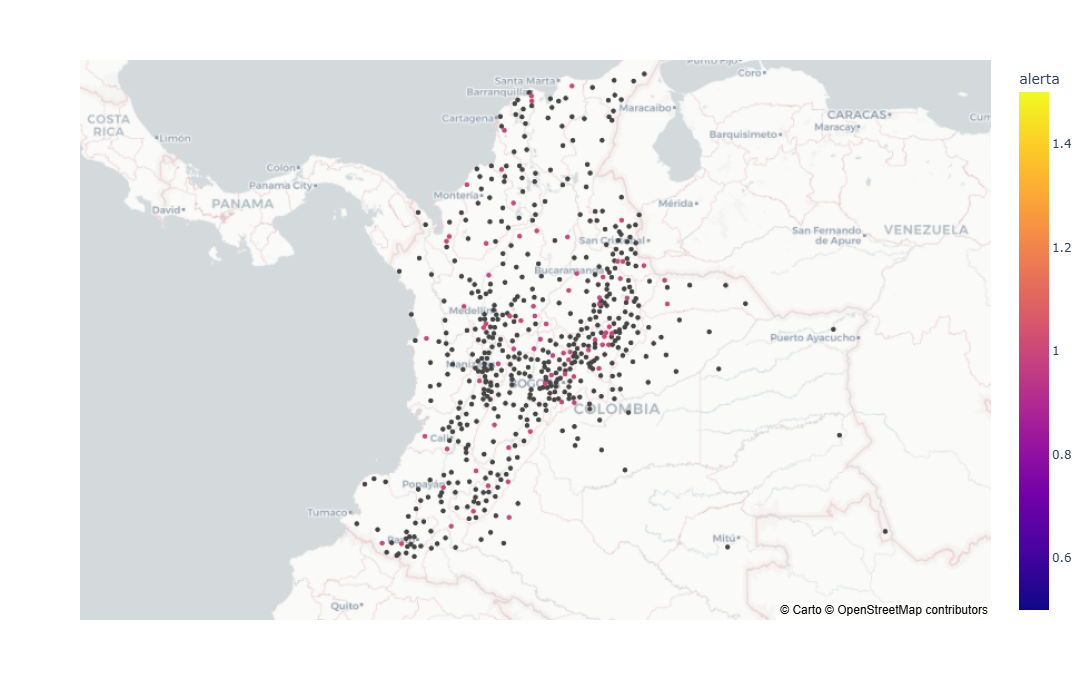

In [ ]:
import plotly.express as px
import pandas as pd

df_mapa = df.copy()

# Asegurar tipos correctos
df_mapa["LATITUD"] = pd.to_numeric(df_mapa["LATITUD"])
df_mapa["LONGITUD"] = pd.to_numeric(df_mapa["LONGITUD"])

fig = px.scatter_mapbox(
    df_mapa,
    lat="LATITUD",
    lon="LONGITUD",
    color="alerta",
    hover_name="NOM_MPIO",  # 👈 este es el nombre grande
    hover_data={
        "alerta": True,
        "LATITUD": False,
        "LONGITUD": False,
        "NOM_DPTO": True
    },
    color_discrete_map={
        0: "lightgray",
        1: "red"
    },
    zoom=5,
    height=700
)

fig.update_layout(mapbox_style="carto-positron")

fig.show()

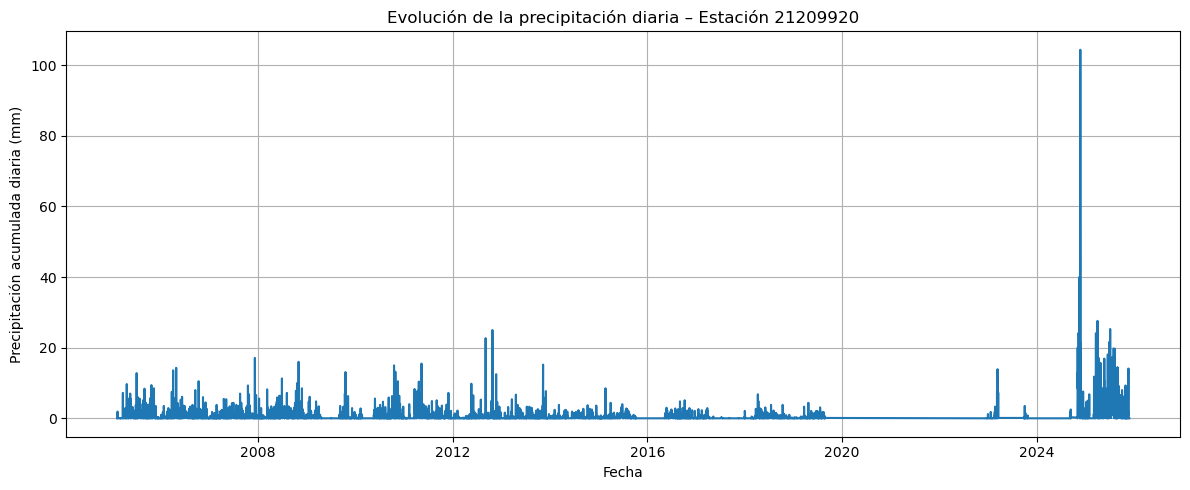

In [ ]:
codigo_estacion=21209920
#gdf_daily_muni=gdf_daily_muni.reset_index()
df_est = (
    gdf_daily_muni
    [gdf_daily_muni["CodigoEstacion"] == codigo_estacion]
    .sort_values("fecha")
)

plt.figure(figsize=(12, 5))
plt.plot(df_est["fecha"], df_est["precip_acum_diaria"])
plt.xlabel("Fecha")
plt.ylabel("Precipitación acumulada diaria (mm)")
plt.title(f"Evolución de la precipitación diaria – Estación {codigo_estacion}")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
gdf_daily_muni.columns

Index(['index_left', 'COD_DPTO', 'NOM_DPTO', 'COD_MPIO', 'NOM_MPIO', 'TIPO',
       'LATITUD', 'LONGITUD', 'Geo Municipio', 'index', 'CodigoEstacion',
       'NombreEstacion', 'Departamento', 'Municipio', 'ZonaHidrografica',
       'Latitud', 'Longitud', 'fecha', 'precip_min_10min', 'precip_max_10min',
       'precip_media_10min', 'precip_acum_diaria', 'geometry', 'dist_m'],
      dtype='object')

In [ ]:
gdf_daily_muni_=gdf_daily_muni[['COD_DPTO', 'NOM_DPTO', 'COD_MPIO', 'NOM_MPIO', 'TIPO',
       'LATITUD', 'LONGITUD', 'Geo Municipio', 'index', 'CodigoEstacion',
       'NombreEstacion','ZonaHidrografica',
       'Latitud', 'Longitud', 'fecha', 'precip_min_10min', 'precip_max_10min',
       'precip_media_10min', 'precip_acum_diaria', 'geometry', 'dist_m']]
gdf_daily_muni_.head()

,COD_DPTO,NOM_DPTO,COD_MPIO,NOM_MPIO,TIPO,LATITUD,LONGITUD,Geo Municipio,index,CodigoEstacion,NombreEstacion,ZonaHidrografica,Latitud,Longitud,fecha,precip_min_10min,precip_max_10min,precip_media_10min,precip_acum_diaria,geometry,dist_m
0,27,CHOCÓ,27160,CÉRTEGUI,Municipio,5.389828,-76.522642,POINT (-76.52264237 5.389828229),0,11017020,PR CHOCO: BAGADO,<nil>,5.412,-76.418,2018-05-04,0.0,3.0,0.147826,3.4,POINT (740539.965 1090713.387),11864.031441
1,27,CHOCÓ,27160,CÉRTEGUI,Municipio,5.389828,-76.522642,POINT (-76.52264237 5.389828229),1,11017020,PR CHOCO: BAGADO,<nil>,5.412,-76.418,2018-05-05,0.0,2.5,0.171429,8.4,POINT (740539.965 1090713.387),11864.031441
2,27,CHOCÓ,27160,CÉRTEGUI,Municipio,5.389828,-76.522642,POINT (-76.52264237 5.389828229),2,11017020,PR CHOCO: BAGADO,<nil>,5.412,-76.418,2018-05-06,0.0,0.0,0.000000,0.0,POINT (740539.965 1090713.387),11864.031441
3,27,CHOCÓ,27160,CÉRTEGUI,Municipio,5.389828,-76.522642,POINT (-76.52264237 5.389828229),3,11017020,PR CHOCO: BAGADO,<nil>,5.412,-76.418,2018-05-07,0.0,6.3,0.206818,9.1,POINT (740539.965 1090713.387),11864.031441
4,27,CHOCÓ,27160,CÉRTEGUI,Municipio,5.389828,-76.522642,POINT (-76.52264237 5.389828229),4,11017020,PR CHOCO: BAGADO,<nil>,5.412,-76.418,2018-05-08,0.0,0.0,0.000000,0.0,POINT (740539.965 1090713.387),11864.031441


In [ ]:
gdf_daily_muni_.to_csv("precipitacion_diaria_por_municipio.csv")

In [ ]:
os.chdir("C:\\Users\\Usuario\\OneDrive - Global Green Growth Institute\\Documentos\\2025\\Stress Test\\Data")
os.listdir()

['202510_Lista de Variables.xlsx',
 'city_scale_climate_hazards_at_1p5_2_3_C_warming',
 'DatosMensuales_HumedadRelativa_SSP126_2021-2100.txt',
 'Escenarios Cambio Climatico IDEAM IV comunicacion',
 'Fuentes de datos.xlsx',
 'GIMODEL',
 'Precipitación_20251222.csv',
 'Precipitación_20251222_2.csv',
 'public_emdat_custom_request_2025-12-17_b73c79c4-e152-4985-bf01-11a89ce1040a.xlsx',
 'Scripts Python',
 'st_datos_colombia.xlsx']

**Datos Mensuales de Escenarios de Cambio Climatico**

In [ ]:
os.chdir("C://Users//Usuario//OneDrive - Global Green Growth Institute//Documentos//2025//Stress Test//Data//Escenarios Cambio Climatico IDEAM IV comunicacion//Mensuales")

In [ ]:
## Cargo los datos de precipitacion 


precipitacion_2021_2100_m=pd.read_csv("DatosMensuales_Precipitacion_SSP126_2021-2100.txt",sep="\t", dtype=str,
    engine="python",header=None,decimal='.')

## Asigno valores a las columnas dado que viene sin nombres


fixed_cols = [
    'ID',
    'Longitud',
    'Latitud',
    'Departamentos',
    'Municipios',
    'Areas Hidrograficas',
    'Zonas Hidrograficas',
    'SubZonas Hidrograficas',
    'RegionPluvHomog_v1_26Reg',
    'RegionPluvHomog_v2_14Reg'
] 


n_total_cols = precipitacion_2021_2100_m.shape[1]
n_date_cols = n_total_cols - len(fixed_cols)

dates = pd.date_range(
    start="2021-01-01",
    periods=n_date_cols,
    freq="MS"  # Month Start
)

data_mensual=precipitacion_2021_2100_m

date_cols = dates.strftime("%Y/%m").tolist()
data_mensual.columns = fixed_cols + date_cols
## Corrección de tiles 
def clean_text(x):
    if not isinstance(x, str):
        return x

    try:
        x = x.encode("latin1").decode("utf-8")
    except:
        pass


    x = re.sub(r"[\x00-\x1f\x7f-\x9f]", "", x)

    x = unicodedata.normalize("NFC", x)

    return x.strip()

text_cols = data_mensual.select_dtypes(include="object").columns
data_mensual[text_cols] = data_mensual[text_cols].applymap(clean_text)

### Data Mensual Precipitacion

gdf_mensual_precipitacion = gpd.GeoDataFrame(data_mensual,
    geometry=gpd.points_from_xy(data_mensual.Longitud, data_mensual.Latitud),
    crs="EPSG:4326"
)
gdf_mensual_precipitacion.head()

,ID,Longitud,Latitud,Departamentos,Municipios,Areas Hidrograficas,Zonas Hidrograficas,SubZonas Hidrograficas,RegionPluvHomog_v1_26Reg,RegionPluvHomog_v2_14Reg,2021/01,2021/02,2021/03,2021/04,2021/05,2021/06,2021/07,2021/08,2021/09,2021/10,2021/11,2021/12,2022/01,2022/02,2022/03,2022/04,2022/05,2022/06,2022/07,2022/08,2022/09,2022/10,2022/11,2022/12,2023/01,2023/02,2023/03,2023/04,2023/05,2023/06,2023/07,2023/08,2023/09,2023/10,2023/11,2023/12,2024/01,2024/02,2024/03,2024/04,2024/05,2024/06,2024/07,2024/08,2024/09,2024/10,2024/11,2024/12,2025/01,2025/02,2025/03,2025/04,2025/05,2025/06,2025/07,2025/08,2025/09,2025/10,2025/11,2025/12,2026/01,2026/02,2026/03,2026/04,2026/05,2026/06,2026/07,2026/08,2026/09,2026/10,2026/11,2026/12,2027/01,2027/02,2027/03,2027/04,2027/05,2027/06,2027/07,2027/08,2027/09,2027/10,2027/11,2027/12,2028/01,2028/02,2028/03,2028/04,2028/05,2028/06,2028/07,2028/08,2028/09,2028/10,2028/11,2028/12,2029/01,2029/02,2029/03,2029/04,2029/05,2029/06,2029/07,2029/08,2029/09,2029/10,2029/11,2029/12,2030/01,2030/02,2030/03,2030/04,2030/05,2030/06,2030/07,2030/08,2030/09,2030/10,2030/11,2030/12,2031/01,2031/02,2031/03,2031/04,2031/05,2031/06,2031/07,2031/08,2031/09,2031/10,2031/11,2031/12,2032/01,2032/02,2032/03,2032/04,2032/05,2032/06,2032/07,2032/08,2032/09,2032/10,2032/11,2032/12,2033/01,2033/02,2033/03,2033/04,2033/05,2033/06,2033/07,2033/08,2033/09,2033/10,2033/11,2033/12,2034/01,2034/02,2034/03,2034/04,2034/05,2034/06,2034/07,2034/08,2034/09,2034/10,2034/11,2034/12,2035/01,2035/02,2035/03,2035/04,2035/05,2035/06,2035/07,2035/08,2035/09,2035/10,2035/11,2035/12,2036/01,2036/02,2036/03,2036/04,2036/05,2036/06,2036/07,2036/08,2036/09,2036/10,2036/11,2036/12,2037/01,2037/02,2037/03,2037/04,2037/05,2037/06,2037/07,2037/08,2037/09,2037/10,2037/11,2037/12,2038/01,2038/02,2038/03,2038/04,2038/05,2038/06,2038/07,2038/08,2038/09,2038/10,2038/11,2038/12,2039/01,2039/02,2039/03,2039/04,2039/05,2039/06,2039/07,2039/08,2039/09,2039/10,2039/11,2039/12,2040/01,2040/02,2040/03,2040/04,2040/05,2040/06,2040/07,2040/08,2040/09,2040/10,2040/11,2040/12,2041/01,2041/02,2041/03,2041/04,2041/05,2041/06,2041/07,2041/08,2041/09,2041/10,2041/11,2041/12,2042/01,2042/02,2042/03,2042/04,2042/05,2042/06,2042/07,2042/08,2042/09,2042/10,2042/11,2042/12,2043/01,2043/02,2043/03,2043/04,2043/05,2043/06,2043/07,2043/08,2043/09,2043/10,2043/11,2043/12,2044/01,2044/02,2044/03,2044/04,2044/05,2044/06,2044/07,2044/08,2044/09,2044/10,2044/11,2044/12,2045/01,2045/02,2045/03,2045/04,2045/05,2045/06,2045/07,2045/08,2045/09,2045/10,2045/11,2045/12,2046/01,2046/02,2046/03,2046/04,2046/05,2046/06,2046/07,2046/08,2046/09,2046/10,2046/11,2046/12,2047/01,2047/02,2047/03,2047/04,2047/05,2047/06,2047/07,2047/08,2047/09,2047/10,2047/11,2047/12,2048/01,2048/02,2048/03,2048/04,2048/05,2048/06,2048/07,2048/08,2048/09,2048/10,2048/11,2048/12,2049/01,2049/02,2049/03,2049/04,2049/05,2049/06,2049/07,2049/08,2049/09,2049/10,2049/11,2049/12,2050/01,2050/02,2050/03,2050/04,2050/05,2050/06,2050/07,2050/08,2050/09,2050/10,2050/11,2050/12,2051/01,2051/02,2051/03,2051/04,2051/05,2051/06,2051/07,2051/08,2051/09,2051/10,2051/11,2051/12,2052/01,2052/02,2052/03,2052/04,2052/05,2052/06,2052/07,2052/08,2052/09,2052/10,2052/11,2052/12,2053/01,2053/02,2053/03,2053/04,2053/05,2053/06,2053/07,2053/08,2053/09,2053/10,2053/11,2053/12,2054/01,2054/02,2054/03,2054/04,2054/05,2054/06,2054/07,2054/08,2054/09,2054/10,2054/11,2054/12,2055/01,2055/02,2055/03,2055/04,2055/05,2055/06,2055/07,2055/08,2055/09,2055/10,2055/11,2055/12,2056/01,2056/02,2056/03,2056/04,2056/05,2056/06,2056/07,2056/08,2056/09,2056/10,2056/11,2056/12,2057/01,2057/02,2057/03,2057/04,2057/05,2057/06,2057/07,2057/08,2057/09,2057/10,2057/11,2057/12,2058/01,2058/02,2058/03,2058/04,2058/05,2058/06,2058/07,2058/08,2058/09,2058/10,2058/11,2058/12,2059/01,2059/02,2059/03,2059/04,2059/05,2059/06,2059/07,2059/08,2059/09,2059/10,2059/11,2059/12,2060/01,2060/02,2060/03,2060/04,2060/05,2060/06,2060/07,2060/08,2060/09,2060/10,2060/11,2060/12,2

In [ ]:
davipola=pd.read_excel("davipola_dane.xlsx")
print(davipola.shape)
davipola.head()
gdf_mun = gdf_mun.to_crs(epsg=3116)

(1121, 8)


In [ ]:
gdf_mun = gpd.GeoDataFrame(davipola,
    geometry=gpd.points_from_xy(davipola.LONGITUD, davipola.LATITUD),
    crs="EPSG:4326"
)

gdf_mensual_precipitacion= gdf_mensual_precipitacion.to_crs(epsg=3116) 
gdf_mun = gdf_mun.to_crs(epsg=3116)

## Unir por los puntos más cercanos

gdf_municipios=gpd.sjoin_nearest(gdf_mun,gdf_mensual_precipitacion, distance_col="dist_m")
gdf_municipios.head()

,COD_DPTO,NOM_DPTO,COD_MPIO,NOM_MPIO,TIPO,LATITUD,LONGITUD,Geo Municipio,geometry,index_right,ID,Longitud,Latitud,Departamentos,Municipios,Areas Hidrograficas,Zonas Hidrograficas,SubZonas Hidrograficas,RegionPluvHomog_v1_26Reg,RegionPluvHomog_v2_14Reg,2021/01,2021/02,2021/03,2021/04,2021/05,2021/06,2021/07,2021/08,2021/09,2021/10,2021/11,2021/12,2022/01,2022/02,2022/03,2022/04,2022/05,2022/06,2022/07,2022/08,2022/09,2022/10,2022/11,2022/12,2023/01,2023/02,2023/03,2023/04,2023/05,2023/06,2023/07,2023/08,2023/09,2023/10,2023/11,2023/12,2024/01,2024/02,2024/03,2024/04,2024/05,2024/06,2024/07,2024/08,2024/09,2024/10,2024/11,2024/12,2025/01,2025/02,2025/03,2025/04,2025/05,2025/06,2025/07,2025/08,2025/09,2025/10,2025/11,2025/12,2026/01,2026/02,2026/03,2026/04,2026/05,2026/06,2026/07,2026/08,2026/09,2026/10,2026/11,2026/12,2027/01,2027/02,2027/03,2027/04,2027/05,2027/06,2027/07,2027/08,2027/09,2027/10,2027/11,2027/12,2028/01,2028/02,2028/03,2028/04,2028/05,2028/06,2028/07,2028/08,2028/09,2028/10,2028/11,2028/12,2029/01,2029/02,2029/03,2029/04,2029/05,2029/06,2029/07,2029/08,2029/09,2029/10,2029/11,2029/12,2030/01,2030/02,2030/03,2030/04,2030/05,2030/06,2030/07,2030/08,2030/09,2030/10,2030/11,2030/12,2031/01,2031/02,2031/03,2031/04,2031/05,2031/06,2031/07,2031/08,2031/09,2031/10,2031/11,2031/12,2032/01,2032/02,2032/03,2032/04,2032/05,2032/06,2032/07,2032/08,2032/09,2032/10,2032/11,2032/12,2033/01,2033/02,2033/03,2033/04,2033/05,2033/06,2033/07,2033/08,2033/09,2033/10,2033/11,2033/12,2034/01,2034/02,2034/03,2034/04,2034/05,2034/06,2034/07,2034/08,2034/09,2034/10,2034/11,2034/12,2035/01,2035/02,2035/03,2035/04,2035/05,2035/06,2035/07,2035/08,2035/09,2035/10,2035/11,2035/12,2036/01,2036/02,2036/03,2036/04,2036/05,2036/06,2036/07,2036/08,2036/09,2036/10,2036/11,2036/12,2037/01,2037/02,2037/03,2037/04,2037/05,2037/06,2037/07,2037/08,2037/09,2037/10,2037/11,2037/12,2038/01,2038/02,2038/03,2038/04,2038/05,2038/06,2038/07,2038/08,2038/09,2038/10,2038/11,2038/12,2039/01,2039/02,2039/03,2039/04,2039/05,2039/06,2039/07,2039/08,2039/09,2039/10,2039/11,2039/12,2040/01,2040/02,2040/03,2040/04,2040/05,2040/06,2040/07,2040/08,2040/09,2040/10,2040/11,2040/12,2041/01,2041/02,2041/03,2041/04,2041/05,2041/06,2041/07,2041/08,2041/09,2041/10,2041/11,2041/12,2042/01,2042/02,2042/03,2042/04,2042/05,2042/06,2042/07,2042/08,2042/09,2042/10,2042/11,2042/12,2043/01,2043/02,2043/03,2043/04,2043/05,2043/06,2043/07,2043/08,2043/09,2043/10,2043/11,2043/12,2044/01,2044/02,2044/03,2044/04,2044/05,2044/06,2044/07,2044/08,2044/09,2044/10,2044/11,2044/12,2045/01,2045/02,2045/03,2045/04,2045/05,2045/06,2045/07,2045/08,2045/09,2045/10,2045/11,2045/12,2046/01,2046/02,2046/03,2046/04,2046/05,2046/06,2046/07,2046/08,2046/09,2046/10,2046/11,2046/12,2047/01,2047/02,2047/03,2047/04,2047/05,2047/06,2047/07,2047/08,2047/09,2047/10,2047/11,2047/12,2048/01,2048/02,2048/03,2048/04,2048/05,2048/06,2048/07,2048/08,2048/09,2048/10,2048/11,2048/12,2049/01,2049/02,2049/03,2049/04,2049/05,2049/06,2049/07,2049/08,2049/09,2049/10,2049/11,2049/12,2050/01,2050/02,2050/03,2050/04,2050/05,2050/06,2050/07,2050/08,2050/09,2050/10,2050/11,2050/12,2051/01,2051/02,2051/03,2051/04,2051/05,2051/06,2051/07,2051/08,2051/09,2051/10,2051/11,2051/12,2052/01,2052/02,2052/03,2052/04,2052/05,2052/06,2052/07,2052/08,2052/09,2052/10,2052/11,2052/12,2053/01,2053/02,2053/03,2053/04,2053/05,2053/06,2053/07,2053/08,2053/09,2053/10,2053/11,2053/12,2054/01,2054/02,2054/03,2054/04,2054/05,2054/06,2054/07,2054/08,2054/09,2054/10,2054/11,2054/12,2055/01,2055/02,2055/03,2055/04,2055/05,2055/06,2055/07,2055/08,2055/09,2055/10,2055/11,2055/12,2056/01,2056/02,2056/03,2056/04,2056/05,2056/06,2056/07,2056/08,2056/09,2056/10,2056/11,2056/12,2057/01,2057/02,2057/03,2057/04,2057/05,2057/06,2057/07,2057/08,2057/09,2057/10,2057/11,2057/12,2058/01,2058/02,2058/03,2058/04,2058/05,2058/06,2058/07,2058/08,2058/09,2058/10,2058/11,2058/12,2059/01,2059/02,2059/03,2059/04,2059/05,2059/06,2059/07,2059/08,2059/09,2059/10,2059/11,2059/12,2060

In [ ]:
gdf_municipios.to_excel("escenarios_precipitacion_2021_20100.xlsx")

**Directamente desde la API**

In [ ]:
pip install sodapy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sodapy import Socrata
import pandas as pd

APP_TOKEN = None 

client = Socrata(
    "www.datos.gov.co",
    APP_TOKEN
)

DATASET_ID = "s54a-sgyg"

max_date_response = client.get(
    DATASET_ID,
    select="max(fechaobservacion)"
)

max_date = max_date_response[0]["max_fechaobservacion"]

print("Última fecha disponible:", max_date)
date_only = max_date[:10]
limit = 1200000
offset = 0
all_results = []

where_condition = (
    f"fechaobservacion >= '{date_only}T00:00:00' "
    f"AND fechaobservacion < '{date_only}T23:59:59.999'"
)

while True:
    batch = client.get(
        DATASET_ID,
        where=where_condition,
        limit=limit,
        offset=offset
    )

    if not batch:
        break

    all_results.extend(batch)
    offset += limit
    print(f"Descargados {len(all_results)} registros...")

df = pd.DataFrame.from_records(all_results)

print("Total registros descargados:", len(df))

if "fechaobservacion" in df.columns:
    df["fechaobservacion"] = pd.to_datetime(df["fechaobservacion"])

client.close()
df.head()      

Última fecha disponible: 2026-03-01T23:59:00.000
Descargados 89121 registros...
Total registros descargados: 89121


,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
0,0042077020,0240,2026-03-01,0,MITU,VAUPES,MITÚ,VAUPES,1.259806,-70.239167,PRECIPITACIÓN,mm
1,0024035360,0240,2026-03-01,0,SOCHA,BOYACÁ,SOCHA,SOGAMOSO,5.985416667,-72.99702778,PRECIPITACIÓN,mm
2,0016015501,0257,2026-03-01,0,AEROPUERTO CAMILO DAZA,NORTE DE SANTANDER,CÚCUTA,CATATUMBO,7.93028,-72.50917,GPRS - PRECIPITACIÓN,mm
3,0024037030,0240,2026-03-01,0,EL PALO,BOYACÁ,TUTA,SOGAMOSO,5.681722222,-73.23113889,PRECIPITACIÓN,mm
4,0015070080,0240,2026-03-01,0,KAURAQUIMANA,LA GUAJIRA,URIBIA,CARIBE - GUAJIRA,12.21836111,-71.45869444,PRECIPITACIÓN,mm
